In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_style("whitegrid")
from google.colab import files
uploaded = files.upload()


In [5]:
df = pd.read_csv("Churn_Modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [9]:
df.shape
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [10]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [12]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [13]:

df.tail()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


In [14]:
df.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


**Observation**

No missing values were found in the dataset.

In [15]:
df.duplicated().sum()

np.int64(0)

**Observation**

No duplicate records were found.

In [20]:
print(df.columns.tolist())

['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


**Exploratory Data Analysis Visualization**

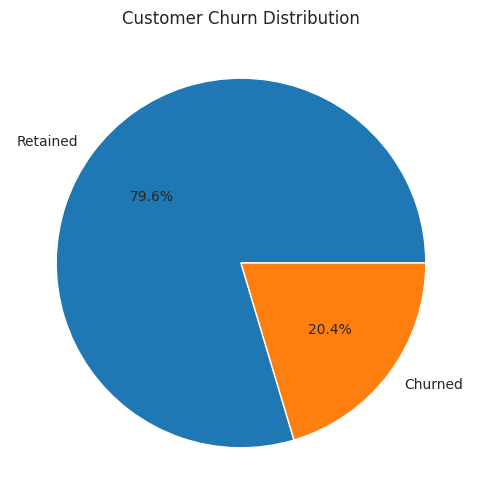

In [25]:
plt.figure(figsize=(6,6))

df['Exited'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    labels=['Retained','Churned']
)

plt.title("Customer Churn Distribution")

plt.ylabel("")

plt.show()

Around 20% of customers left the bank, while nearly 80% remained.

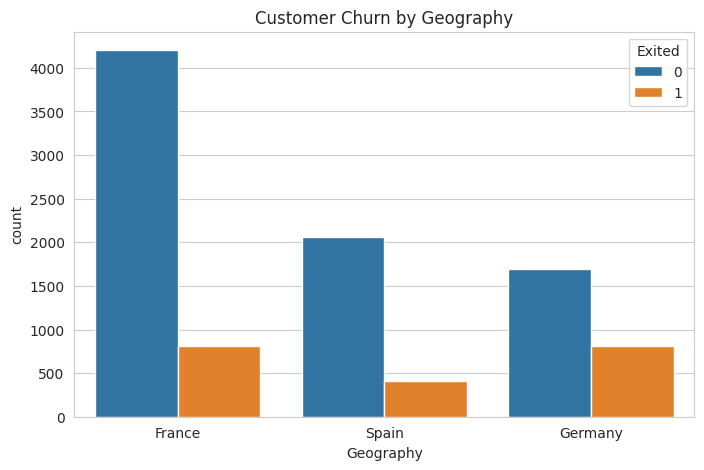

In [26]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Geography',
    hue='Exited'
)

plt.title("Customer Churn by Geography")

plt.show()

France has the highest number of churned customers.

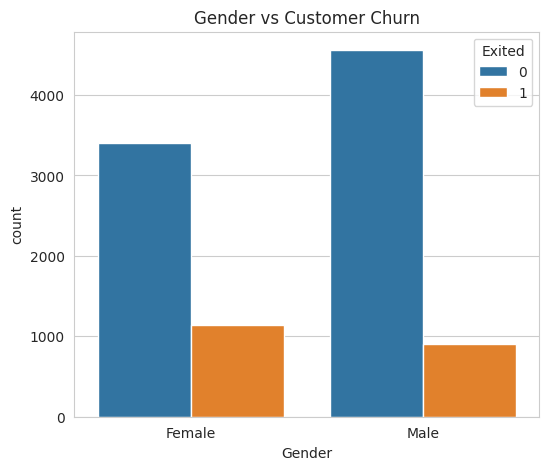

In [27]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x='Gender',
    hue='Exited'
)

plt.title("Gender vs Customer Churn")

plt.show()

Although the dataset contains more male customers overall, female customers have a higher churn rate, indicating that a larger proportion of female customers leave the bank compared to male customers.

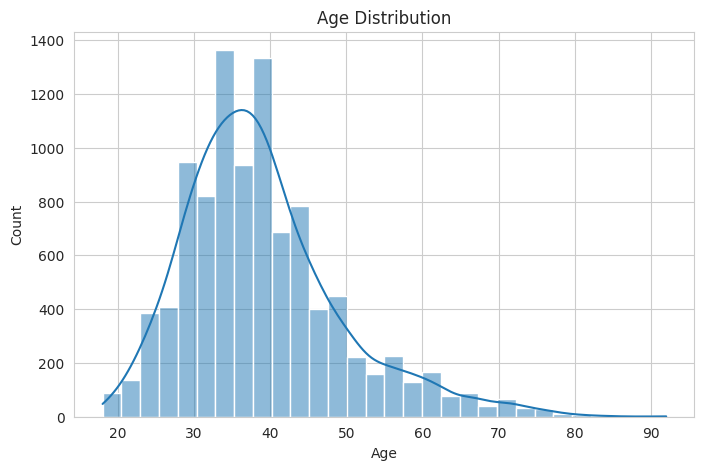

In [28]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Age'],
    bins=30,
    kde=True
)

plt.title("Age Distribution")

plt.show()

**Creating Age Groups**

In [29]:
bins = [18,30,40,50,60,100]

labels = ['18-29','30-39','40-49','50-59','60+']

df['AgeGroup'] = pd.cut(df['Age'],bins=bins,labels=labels)

**Now plot**

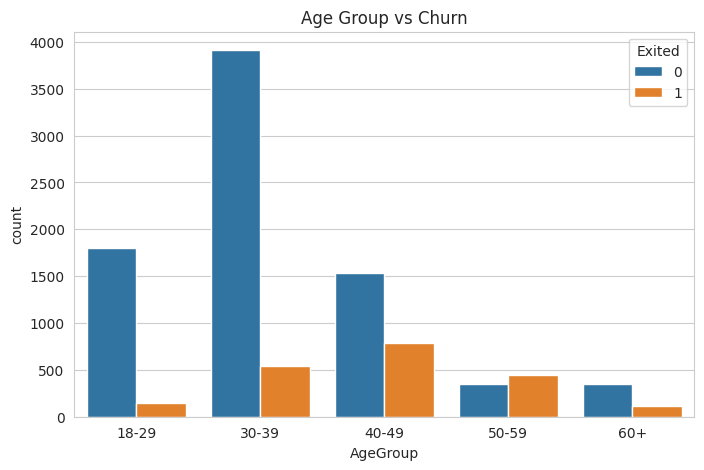

In [30]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='AgeGroup',
    hue='Exited'
)

plt.title("Age Group vs Churn")

plt.show()

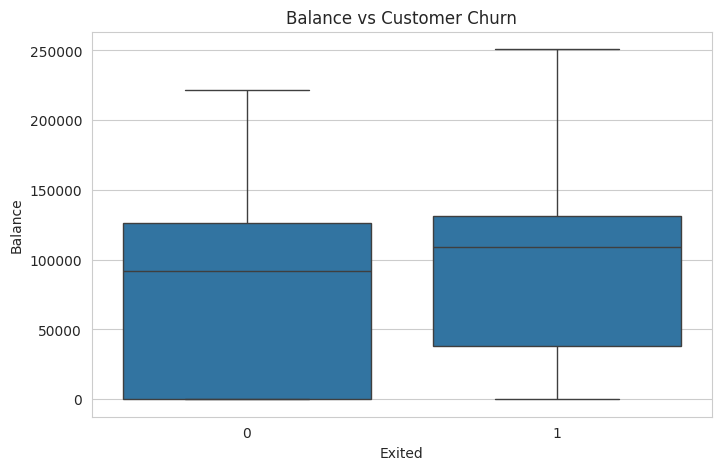

In [31]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Exited',
    y='Balance'
)

plt.title("Balance vs Customer Churn")

plt.show()

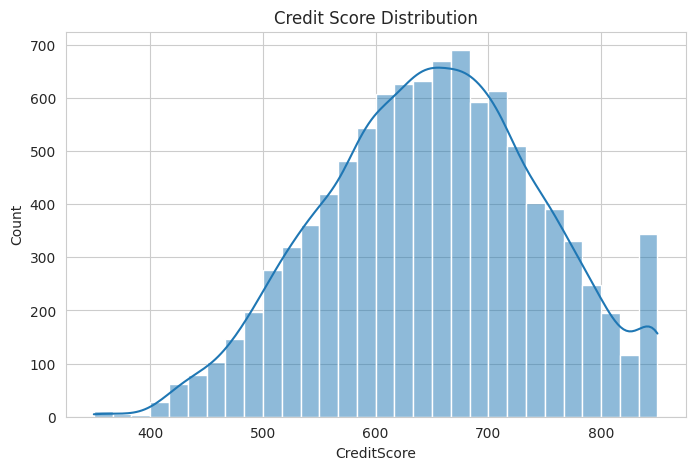

In [32]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['CreditScore'],
    bins=30,
    kde=True
)

plt.title("Credit Score Distribution")

plt.show()

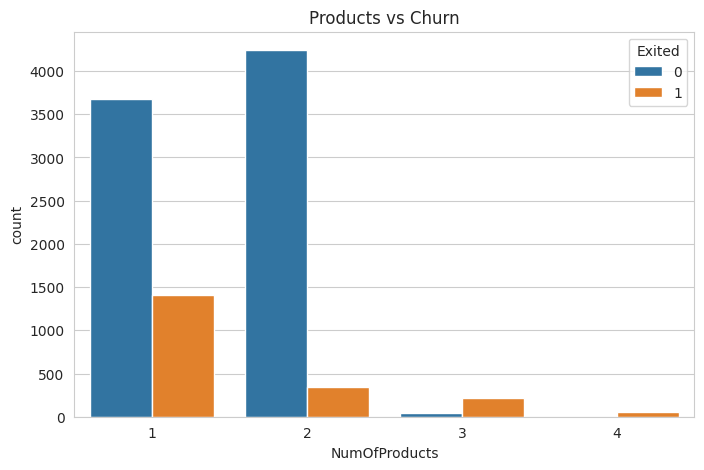

In [33]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='NumOfProducts',
    hue='Exited'
)

plt.title("Products vs Churn")

plt.show()

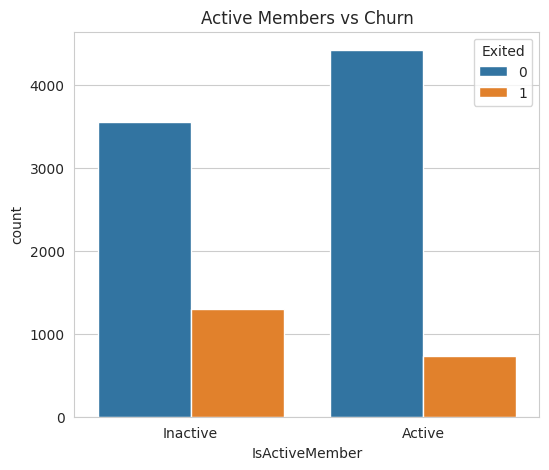

In [34]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x='IsActiveMember',
    hue='Exited'
)

plt.xticks([0,1],['Inactive','Active'])

plt.title("Active Members vs Churn")

plt.show()

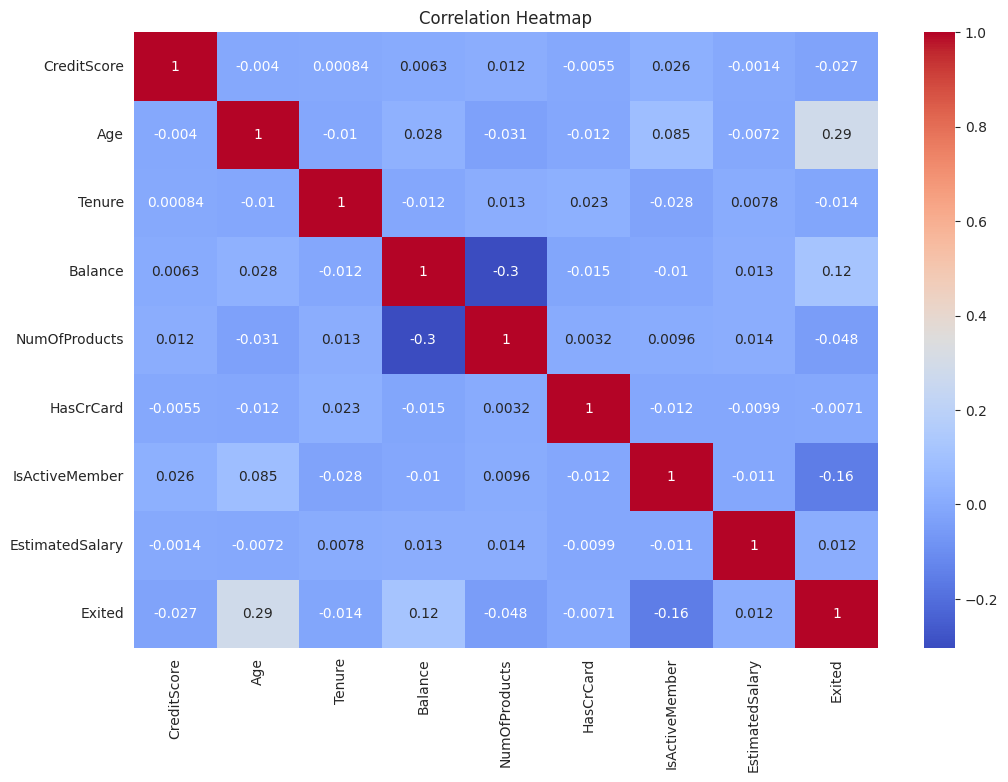

In [35]:
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

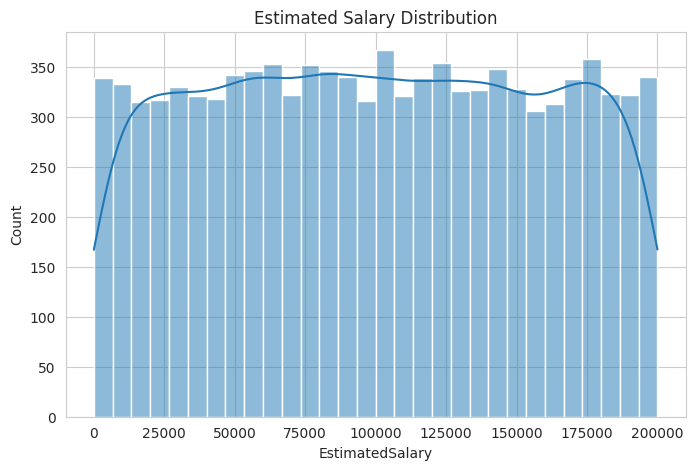

In [36]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['EstimatedSalary'],
    bins=30,
    kde=True
)

plt.title("Estimated Salary Distribution")

plt.show()

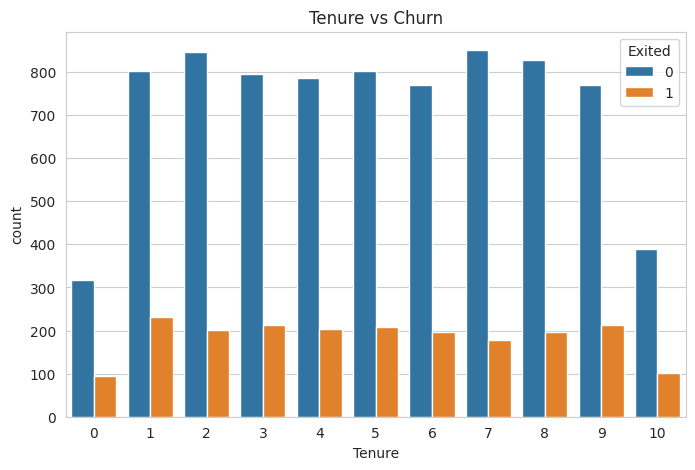

In [37]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Tenure',
    hue='Exited'
)

plt.title("Tenure vs Churn")

plt.show()

**Key Insights**

*  Overall customer churn rate is approximately 20%, indicating that one in five customers left the bank.
*   Customers with only one banking product show a significantly higher churn rate than those with multiple products.
*   France has the highest customer churn among all regions.
*   Inactive members are more likely to churn than active members.
*   Customers aged 40–60 years have higher churn compared to younger customers.
*   Gender shows some variation in churn, with one group exhibiting a slightly higher churn rate.
*   Customers with higher account balances appear more likely to churn.
*   Credit score has a relatively weaker relationship with churn compared to variables such as product count and customer activity.
*   Age, number of products, and active membership status emerge as key factors influencing customer churn.











